# Лекция 6: Image Segmentation

**План лекции:**

1. ~~Постановка задачи~~
3. ~~Метрики~~
4. ~~Функции потерь~~
5. ~~Семантическая сегментация~~
6. ~~Инстанс сегментация~~
7. ~~Трансформеры в сегментации~~
8. SAM

# 6. Segment Anything Model (SAM, Meta AI, 2023)

![sam](assets/sam.jpg)

Segment Anything Model (SAM) — универсальная модель сегментации, представленная Meta AI в 2023 году.

**Главная фишка SAM** - возможность предсказаний в формате zero-shot (произвольные объекты без дообучения)

---

## Основная идея

SAM решает задачу **условной сегментации**:

$$
M = f(I, c)
$$

где

- $I$ — изображение  
- $c$ — сигнал (prompt)  
- $M$ — предсказанная маска

Prompt может задавать **какой объект сегментировать**.


| Prompt | Описание |
|------|------|
| Point prompt | точка с меткой foreground/background |
| Box prompt | bounding box |
| Mask prompt | упрощенная маска |

Текстовые prompt напрямую **не поддерживаются** в стандартной версии SAM, но авторы доказали возможность такого подхода (процедура обучения модифицируется и используются embeddings модели CLIP).

---

## Архитектура SAM

Модель состоит из трёх основных компонентов:

1. **Image Encoder**
2. **Prompt Encoder**
3. **Mask Decoder**


## Image Encoder

Image encoder кодирует изображение в пространственные признаки.

В SAM используется **Vision Transformer (ViT)**.

Пусть входное изображение:

$$
I \in \mathbb{R}^{H \times W \times 3}
$$

Image encoder вычисляет embedding изображения:

$$
F = E_{img}(I)
$$

где

$$
F \in \mathbb{R}^{h \times w \times D}
$$

- $h = H/P$
- $w = W/P$
- $P$ — размер patch (обычно 16)
- $D$ — размерность embedding

Эти признаки используются в дальнейшем для сегментации.

---

## Prompt Encoder

Prompt encoder преобразует пользовательские запросы в embeddings.

Он возвращает **два типа признаков**:

- **Sparse prompt embeddings**  
- **Dense prompt embeddings**

**Sparse Prompt Embeddings**

Sparse embeddings соответствуют:

- точкам
- bounding boxes

Каждая точка кодируется как:

$$
e_{point} =
PE(x, y) + e_{label}
$$

где

- $PE(x,y)$ — обучаемый positional encoding координат
- $e_{label}$ — обучаемый embedding метки (foreground / background)

Bounding box кодируется через positional encoding его углов.

**Dense Prompt Embeddings**

Dense embeddings используются для промптов в виде маски

Маска сначала приводится к низкому разрешению ($M_\text{down} \in \mathbb{R}^{h \times w}$) и затем кодируется в пространственное представление ($M_\text{down} \in \mathbb{R}^{h \times w \times D}$)

---

## 2.3 Mask Decoder

Mask Decoder в SAM генерирует маску объекта, объединяя **feature map изображения** с **prompt tokens** и **mask tokens**.  


### Шаг 1: Подготовка входов

1. **Feature map изображения** из image encoder:

$$
F \in \mathbb{R}^{h \times w \times D}
$$

2. **Prompt tokens**:  
   - sparse tokens для точек/box  
   - dense tokens для пользовательской маски (если есть)

3. **Mask tokens**: обучаемые вектора $t_i \in \mathbb{R}^D\$, каждый создаёт одну candidate mask.

4. Объединяем все токены в набор:
$$
T = \{\text{mask tokens} + \text{prompt tokens}\}
$$


### Шаг 2: Cross-Attention

- Каждый токен $t_i$ проходит через  **cross-attention** с feature map $F$:

$$
z_i = \text{DecoderLayer}(t_i, F)
$$



### Шаг 3: Генерация динамического фильтра

- Каждый токен $z_i$ пропускается через небольшой MLP:

$$
w_i = \text{MLP}(z_i) \in \mathbb{R}^D
$$

- Этот вектор $w_i$ играет роль **динамического фильтра**, который выбирает признаки из feature map для генерации маски.



### Шаг 4: Вычисление mask logits

- Маска на каждой позиции $(x,y)$ вычисляется как **скалярное произведение**:

$$
\hat{M}_i(x,y) = w_i^\top F(x,y)
$$

- Получаем **mask logits** для каждой mask token.

- Если есть dense mask prompt, она добавляется в cross-attention, корректируя маску.



### Шаг 5: Upsampling и бинаризация

- Mask logits интерполируются до исходного размера изображения \(H \times W\):

$$
\hat{M}_i \in \mathbb{R}^{H \times W}
$$

- Применяется sigmoid и threshold $t$ для получения бинарной маски:

$$
M_i = \sigma(\hat{M}_i - t)
$$


### Шаг 6: Итог

- Каждая mask token генерирует одну candidate mask.  
- Prompt tokens направляют decoder, какую область выделять.  
- Decoder предсказывает несколько кандидатов. Для каждой маски вычисляется **IoU score**, который оценивает качество маски

____

## Функции потерь

Для обучения используются стандартные функции потерь сегментации.

**Dice Loss**

$$
\mathcal{L}_{dice} =
1 - \frac{2 \sum_i p_i g_i}
{\sum_i p_i + \sum_i g_i + \epsilon}
$$

**Binary Cross Entropy**

$$
\mathcal{L}_{BCE} =
-\frac{1}{N}\sum_i
\left[
g_i\log(p_i) +
(1-g_i)\log(1-p_i)
\right]
$$

**Общий Loss**

$$
\mathcal{L} =
\lambda_1 \mathcal{L}_{dice}
+
\lambda_2 \mathcal{L}_{BCE}
$$

____

## Почему SAM работает

1. Большой датасет
   SA-1B обеспечивает огромную вариативность объектов.

2. Prompt-conditioned segmentation

    SAM обучается решать задачу
    
    $$
    M = f(I, prompt)
    $$
    
    а не классифицировать пиксели.

3. Универсальный decoder

    Mask decoder фактически работает как **conditional mask generator**, который может принимать различные типы сигналов.


In [2]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2026-03-11 18:21:06--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving proxy.tcsbank.ru (proxy.tcsbank.ru)... 10.218.6.49, 10.218.11.50, 10.218.6.48, ...
Connecting to proxy.tcsbank.ru (proxy.tcsbank.ru)|10.218.6.49|:8080... connected.
Proxy tunneling failed: URLBlockedUnable to establish SSL connection.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from PIL import Image
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator


sam = sam_model_registry["vit_b"](checkpoint="assets/sam_vit_b_01ec64.pth")
predictor = SamPredictor(sam)


def show_mask(mask: np.ndarray[np.bool_], ax: Axes, random_color: bool = False) -> None:
    
    if random_color:
        color = np.concatenate([np.random.random(3), [0.6]])
    else:
        color = np.array([1, 1, 1, 0.6])

    h, w = mask.shape

    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, 4)
    ax.imshow(mask_image)


def show_points(
    coords: np.ndarray[np.int_], labels: np.ndarray[np.int_], ax: Axes
) -> None:

    pos_points: np.ndarray[np.int_] = coords[labels == 1]
    neg_points: np.ndarray[np.int_] = coords[labels == 0]

    ax.scatter(
        pos_points[:, 0],
        pos_points[:, 1],
        color="green",
        marker="*",
        s=200,
    )

    ax.scatter(
        neg_points[:, 0],
        neg_points[:, 1],
        color="red",
        marker="*",
        s=200,
    )

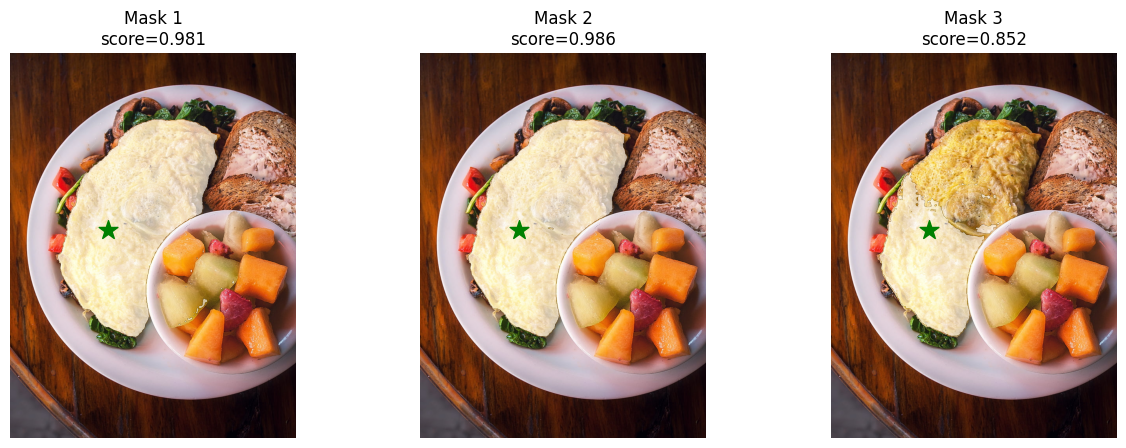

In [40]:
# загрузка изображения
img = np.array(Image.open("assets/food.jpg").convert("RGB"))
predictor.set_image(img)

# prompt
point_coords = np.array([[250, 450]])  # (x, y)
point_labels = np.array([1])           # foreground

# инференс
masks, scores, logits = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True
)

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, (mask, score) in enumerate(zip(masks, scores)):
    
    ax = axes[i]
    ax.imshow(img)
    
    show_mask(mask, ax)
    show_points(point_coords, point_labels, ax)
    
    ax.set_title(f"Mask {i+1}\nscore={score:.3f}")
    ax.axis('off')

plt.show()

Автоматическая разметка изображения

Количество масок: 40
После фильтрации: 29


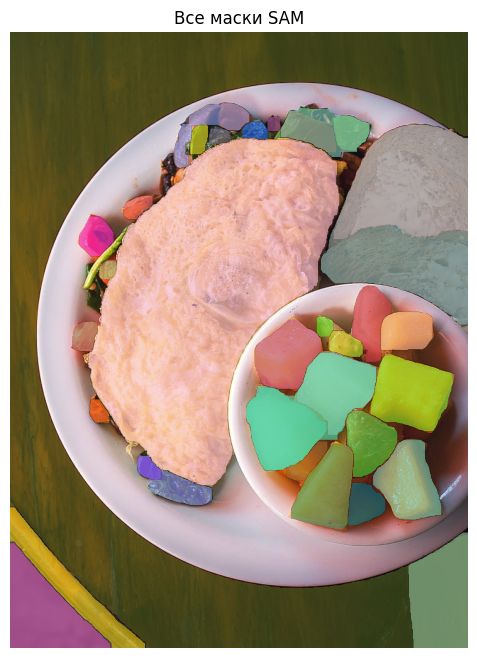

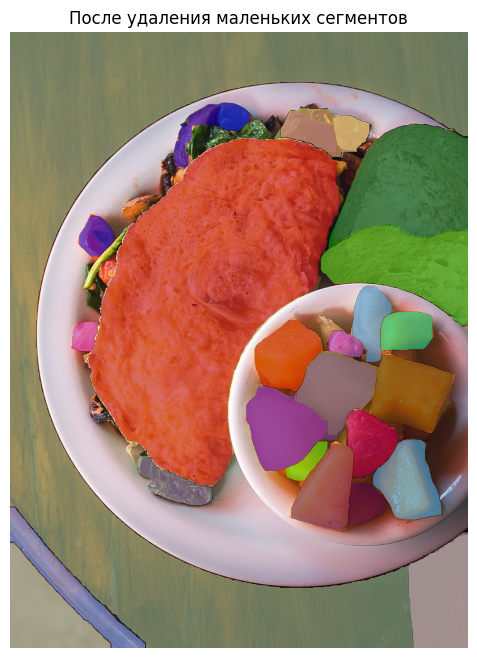

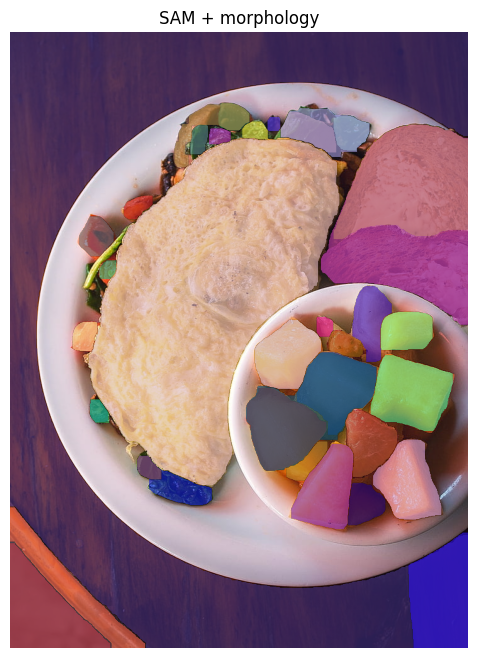

In [ ]:
# Убираем мелкие маски
def filter_small_masks(
    masks: list[dict],
    min_area: int = 2000
) -> list[dict]:

    filtered_masks = []

    for m in masks:
        if m["area"] > min_area:
            filtered_masks.append(m)

    return filtered_masks


# Морфологическая очистка масок
def clean_mask(mask: np.ndarray) -> np.ndarray:

    mask_uint8 = mask.astype(np.uint8) * 255

    kernel = np.ones((15,15), np.uint8)

    # Закрытие: удаляем маленькие отверстия внутри объекта
    mask_closed = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, kernel)
    
    # Опционально: открытие для удаления мелких шумов
    mask_clean = cv2.morphologyEx(mask_closed, cv2.MORPH_OPEN, kernel)

    return mask_clean > 0


def show_all_masks(img, masks):

    plt.figure(figsize=(8,8))
    plt.imshow(img)

    for m in masks:
        show_mask(m["segmentation"], plt.gca(), random_color=True)

    plt.axis("off")


# mask_generator = SamAutomaticMaskGenerator(sam)
# auto_masks = mask_generator.generate(img)
print("Количество масок:", len(auto_masks))

filtered_masks = filter_small_masks(auto_masks, min_area=1500)
print("После фильтрации:", len(filtered_masks))

show_all_masks(img, auto_masks)
plt.title("Все маски SAM")
show_all_masks(img, filtered_masks)
plt.title("После удаления маленьких сегментов")

# Применение чистки ко всем маскам
cleaned_masks = []

for m in auto_masks:
    cleaned = clean_mask(m["segmentation"])
    m["segmentation"] = cleaned
    cleaned_masks.append(m)

# Финальная визуализация
show_all_masks(img, cleaned_masks)
_ = plt.title("SAM + morphology")
